# Notebook 2 — Predictive Models for Transaction Risk Assessment

**Task:** Build, evaluate and compare multiple supervised machine-learning models
that assign a fraud-risk probability to every bank transaction.

---
## Table of Contents
1. [Data Loading & Preprocessing](#1)
2. [Fraud Label & Class Distribution](#2)
3. [Feature Engineering & Encoding](#3)
4. [Train / Test Split & Class Imbalance — SMOTE](#4)
5. [Model 1 — Logistic Regression (Baseline)](#5)
6. [Model 2 — Random Forest](#6)
7. [Model 3 — XGBoost](#7)
8. [Model Comparison & ROC Curves](#8)
9. [Feature Importance](#9)
10. [Risk Scoring & Conclusions](#10)


## 1 — Data Loading & Preprocessing <a id='1'></a>

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (classification_report, confusion_matrix,
                                     roc_auc_score, roc_curve,
                                     precision_recall_curve, average_precision_score,
                                     accuracy_score, f1_score,
                                     recall_score, precision_score,
                                     ConfusionMatrixDisplay)
from imblearn.over_sampling  import SMOTE
from xgboost                 import XGBClassifier

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

df_raw = pd.read_csv("bank_transactions_data_2.csv")
print("Raw data shape:", df_raw.shape)
df_raw.head(3)


Raw data shape: (2512, 16)


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04


In [27]:
# Reproduce cleaning pipeline (self-contained -- same seed as Notebook 1)
np.random.seed(42)
df = df_raw.copy()

# 1. Parse dates
df["TransactionDate"]         = pd.to_datetime(df["TransactionDate"])
df["PreviousTransactionDate"] = pd.to_datetime(df["PreviousTransactionDate"])

# 2. Inject nulls (same seed ensures identical rows affected as Notebook 1)
INJECT_COLS = {
    "TransactionAmount":   0.07,
    "CustomerAge":         0.06,
    "TransactionDuration": 0.08,
    "AccountBalance":      0.05,
    "CustomerOccupation":  0.06,
    "Channel":             0.04,
}
for col, frac in INJECT_COLS.items():
    idx = np.random.choice(df.index, size=int(len(df) * frac), replace=False)
    df.loc[idx, col] = np.nan

# 3. Impute (assignment syntax -- avoids pandas CoW issue)
for col in ["TransactionAmount", "CustomerAge", "TransactionDuration", "AccountBalance"]:
    df[col] = df[col].fillna(df[col].median())
for col in ["CustomerOccupation", "Channel"]:
    df[col] = df[col].fillna(df[col].mode()[0])

# 4. Winsorise
def winsorise(s):
    lo, hi = s.quantile(0.01), s.quantile(0.99)
    return s.clip(lo, hi)

for col in ["TransactionAmount", "AccountBalance", "TransactionDuration"]:
    df[col] = winsorise(df[col])

df["CustomerAge"] = df["CustomerAge"].clip(18, 100)

print(f"Cleaned shape : {df.shape}")
print(f"Remaining NaN : {df.isnull().sum().sum()}")


Cleaned shape : (2512, 16)
Remaining NaN : 0


## 2 — Fraud Label & Class Distribution <a id='2'></a>

In [28]:
# Engineer the same IsFraud label as Notebook 1
df["AmountToBalanceRatio"] = df["TransactionAmount"] / df["AccountBalance"]
amount_p95 = df["TransactionAmount"].quantile(0.95)

flag_login      = (df["LoginAttempts"] >= 3).astype(int)
flag_high_ratio = (df["AmountToBalanceRatio"] > 0.5).astype(int)
flag_quick_tx   = (df["TransactionDuration"] < 15).astype(int)
flag_large_tx   = (df["TransactionAmount"] > amount_p95).astype(int)

df["IsFraud"] = (((flag_login + flag_high_ratio + flag_quick_tx + flag_large_tx) >= 2)
                 | (flag_login == 1)).astype(int)

print(f"Fraud transactions : {df['IsFraud'].sum():,}  ({df['IsFraud'].mean()*100:.1f}%)")
print(f"Legit transactions : {(df['IsFraud']==0).sum():,}  ({(df['IsFraud']==0).mean()*100:.1f}%)")


Fraud transactions : 145  (5.8%)
Legit transactions : 2,367  (94.2%)


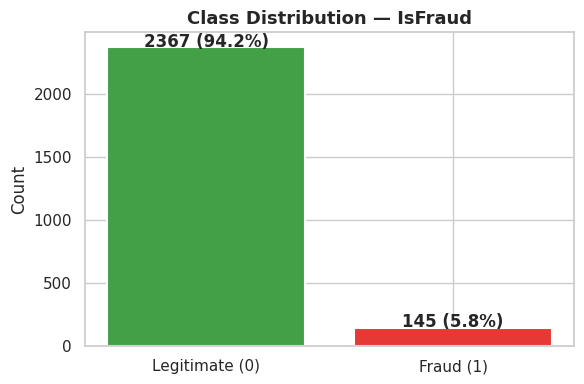

Class imbalance note: without correction, classifiers predict the majority class
(Legitimate) almost exclusively -- achieving high accuracy but terrible recall on Fraud.
We address this with SMOTE in Section 4.


In [29]:
# Class distribution plot
vc = df["IsFraud"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Legitimate (0)","Fraud (1)"], [vc[0], vc[1]],
               color=["#43A047","#E53935"], edgecolor="white", linewidth=1.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{bar.get_height()} ({bar.get_height()/len(df)*100:.1f}%)",
            ha="center", fontweight="bold")
ax.set_title("Class Distribution — IsFraud", fontsize=13, fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print("Class imbalance note: without correction, classifiers predict the majority class")
print("(Legitimate) almost exclusively -- achieving high accuracy but terrible recall on Fraud.")
print("We address this with SMOTE in Section 4.")


## 3 — Feature Engineering & Encoding <a id='3'></a>

In [30]:
# 3.1  Time-based features
df["TxHour"]      = df["TransactionDate"].dt.hour
df["TxDayOfWeek"] = df["TransactionDate"].dt.dayofweek
df["TxMonth"]     = df["TransactionDate"].dt.month
df["IsWeekend"]   = (df["TxDayOfWeek"] >= 5).astype(int)
df["IsNightTime"] = ((df["TxHour"] < 6) | (df["TxHour"] >= 22)).astype(int)

days_diff = (df["PreviousTransactionDate"] - df["TransactionDate"]).dt.days.abs()
df["DaysSincePrevTx"] = days_diff.fillna(days_diff.median())

print("Time features created.")
print(f"Any NaN in DaysSincePrevTx: {df['DaysSincePrevTx'].isnull().sum()}")


Time features created.
Any NaN in DaysSincePrevTx: 0


In [31]:
# 3.2  Label-encode categorical features
# Why Label Encoding?
#   Tree-based models (RF, XGBoost) handle integer-encoded categories natively.
#   LR gets a StandardScaler on top, so ordinal encoding is acceptable here.

cat_cols = ["TransactionType", "Channel", "CustomerOccupation", "Location"]
le_dict  = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le
    print(f"  {col:<22} -> {col}_enc  ({df[col].nunique()} classes)")

print("\nLabel encoding complete.")


  TransactionType        -> TransactionType_enc  (2 classes)
  Channel                -> Channel_enc  (3 classes)
  CustomerOccupation     -> CustomerOccupation_enc  (4 classes)
  Location               -> Location_enc  (43 classes)

Label encoding complete.


In [32]:
# 3.3  Final feature set
FEATURE_COLS = [
    "TransactionAmount",
    "TransactionDuration",
    "LoginAttempts",
    "AccountBalance",
    "CustomerAge",
    "AmountToBalanceRatio",
    "TxHour",
    "TxDayOfWeek",
    "TxMonth",
    "IsWeekend",
    "IsNightTime",
    "DaysSincePrevTx",
    "TransactionType_enc",
    "Channel_enc",
    "CustomerOccupation_enc",
    "Location_enc",
]

X = df[FEATURE_COLS].copy()
y = df["IsFraud"].copy()

# Final NaN check
nan_counts = X.isnull().sum()
if nan_counts.any():
    print("NaNs found -- filling with column medians:")
    for col in nan_counts[nan_counts > 0].index:
        X[col] = X[col].fillna(X[col].median())
        print(f"  {col}: filled")

assert X.isnull().sum().sum() == 0, "NaNs still present!"
print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}  (Fraud={y.sum()}, Legit={(y==0).sum()})")


Feature matrix X : (2512, 16)
Target vector  y : (2512,)  (Fraud=145, Legit=2367)


## 4 — Train / Test Split & Class Imbalance — SMOTE <a id='4'></a>

### Why SMOTE?
- **SMOTE** (Synthetic Minority Over-sampling Technique) generates new synthetic minority
  samples by interpolating between existing ones — unlike random duplication, it adds genuine
  diversity without simply repeating points.
- Applied **only on the training set** — the test set must reflect real-world class proportions.
- Alternative considered: `class_weight='balanced'` — simpler but less effective for significant
  imbalances; SMOTE is the industry standard for financial fraud detection.


In [33]:
# 4.1  Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set : {X_train.shape[0]:,} rows  |  Fraud: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test set     : {X_test.shape[0]:,} rows  |  Fraud: {y_test.sum()} ({y_test.mean()*100:.1f}%)")


Training set : 2,009 rows  |  Fraud: 116 (5.8%)
Test set     : 503 rows  |  Fraud: 29 (5.8%)


In [34]:
# 4.2  Feature scaling (required for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


After SMOTE (unscaled):
  Training rows : 3,786
  Fraud         : 1,893  (50.0%)
  Legit         : 1,893  (50.0%)


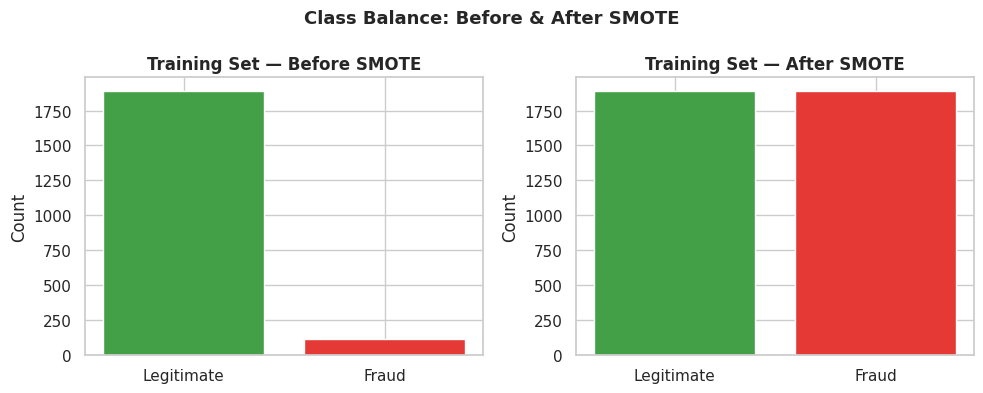

In [35]:
# 4.3  Apply SMOTE to training data
smote = SMOTE(random_state=42, k_neighbors=5)

X_train_sm,    y_train_sm    = smote.fit_resample(X_train,    y_train)
X_train_sc_sm, y_train_sc_sm = smote.fit_resample(X_train_sc, y_train)

print("After SMOTE (unscaled):")
print(f"  Training rows : {len(X_train_sm):,}")
print(f"  Fraud         : {y_train_sm.sum():,}  ({y_train_sm.mean()*100:.1f}%)")
print(f"  Legit         : {(y_train_sm==0).sum():,}  ({(y_train_sm==0).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_s, title in [
    (axes[0], y_train,    "Training Set — Before SMOTE"),
    (axes[1], y_train_sm, "Training Set — After SMOTE"),
]:
    vc = y_s.value_counts()
    ax.bar(["Legitimate","Fraud"], [vc.get(0,0), vc.get(1,0)],
           color=["#43A047","#E53935"])
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Count")
plt.suptitle("Class Balance: Before & After SMOTE", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 5 — Model 1: Logistic Regression (Baseline) <a id='5'></a>



In [36]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train_sc_sm, y_train_sc_sm)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression — Classification Report ===")
print(classification_report(y_test, y_pred_lr, target_names=["Legitimate","Fraud"]))
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}")
print(f"Avg Prec : {average_precision_score(y_test, y_prob_lr):.4f}")


=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99       474
       Fraud       0.72      0.97      0.82        29

    accuracy                           0.98       503
   macro avg       0.86      0.97      0.91       503
weighted avg       0.98      0.98      0.98       503

ROC-AUC  : 0.9945
Avg Prec : 0.9350


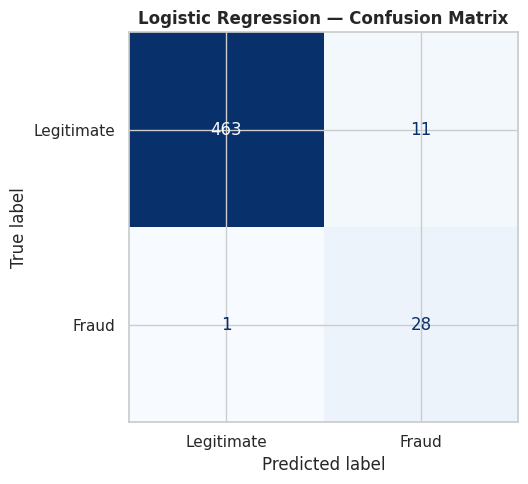

True Positives  (Fraud correctly caught) : 28
False Negatives (Fraud missed)           : 1
False Positives (False alarms)           : 11
True Negatives  (Legit correctly cleared): 463


In [37]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_lr, display_labels=["Legitimate","Fraud"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Logistic Regression — Confusion Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_lr.ravel()
print(f"True Positives  (Fraud correctly caught) : {tp}")
print(f"False Negatives (Fraud missed)           : {fn}")
print(f"False Positives (False alarms)           : {fp}")
print(f"True Negatives  (Legit correctly cleared): {tn}")


## 6 — Model 2: Random Forest <a id='6'></a>



In [38]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest — Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=["Legitimate","Fraud"]))
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"Avg Prec : {average_precision_score(y_test, y_prob_rf):.4f}")


=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       474
       Fraud       0.96      0.93      0.95        29

    accuracy                           0.99       503
   macro avg       0.98      0.96      0.97       503
weighted avg       0.99      0.99      0.99       503

ROC-AUC  : 0.9992
Avg Prec : 0.9900


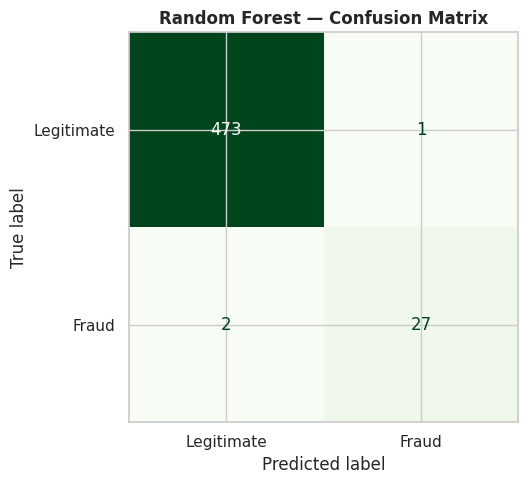

True Positives  (Fraud correctly caught) : 27
False Negatives (Fraud missed)           : 2
False Positives (False alarms)           : 1
True Negatives  (Legit correctly cleared): 473


In [39]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_rf, display_labels=["Legitimate","Fraud"]).plot(
    ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Random Forest — Confusion Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_rf.ravel()
print(f"True Positives  (Fraud correctly caught) : {tp}")
print(f"False Negatives (Fraud missed)           : {fn}")
print(f"False Positives (False alarms)           : {fp}")
print(f"True Negatives  (Legit correctly cleared): {tn}")


## 7 — Model 3: XGBoost <a id='7'></a>




In [40]:
scale_pw = float((y_train_sm == 0).sum()) / max(float((y_train_sm == 1).sum()), 1)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pw,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb  = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost — Classification Report ===")
print(classification_report(y_test, y_pred_xgb, target_names=["Legitimate","Fraud"]))
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"Avg Prec : {average_precision_score(y_test, y_prob_xgb):.4f}")


=== XGBoost — Classification Report ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       474
       Fraud       0.96      0.93      0.95        29

    accuracy                           0.99       503
   macro avg       0.98      0.96      0.97       503
weighted avg       0.99      0.99      0.99       503

ROC-AUC  : 0.9994
Avg Prec : 0.9921


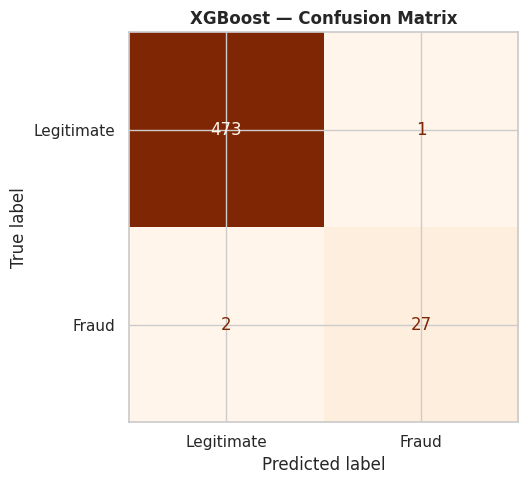

True Positives  (Fraud correctly caught) : 27
False Negatives (Fraud missed)           : 2
False Positives (False alarms)           : 1
True Negatives  (Legit correctly cleared): 473


In [41]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_xgb, display_labels=["Legitimate","Fraud"]).plot(
    ax=ax, cmap="Oranges", colorbar=False)
ax.set_title("XGBoost — Confusion Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_xgb.ravel()
print(f"True Positives  (Fraud correctly caught) : {tp}")
print(f"False Negatives (Fraud missed)           : {fn}")
print(f"False Positives (False alarms)           : {fp}")
print(f"True Negatives  (Legit correctly cleared): {tn}")


## 8 — Model Comparison & ROC Curves <a id='8'></a>

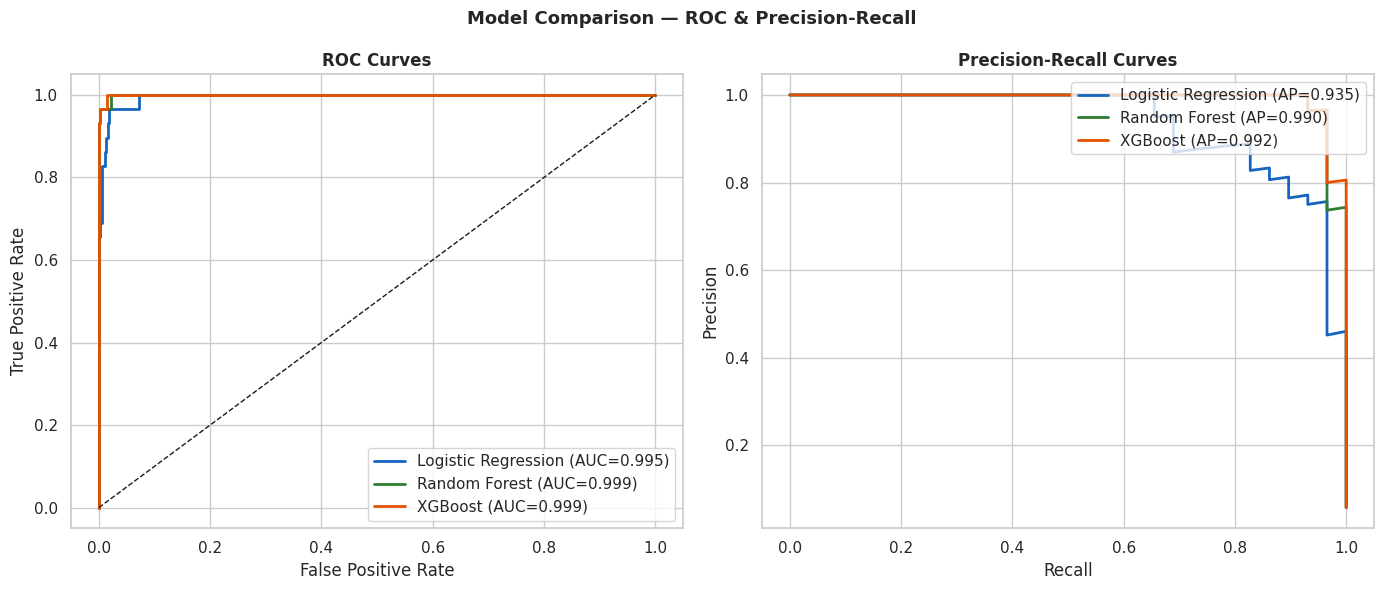

In [42]:
# 8.1  ROC and Precision-Recall curves
models_eval = {
    "Logistic Regression": (y_prob_lr,  "#1565C0"),
    "Random Forest"       : (y_prob_rf,  "#2E7D32"),
    "XGBoost"             : (y_prob_xgb, "#E65100"),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for name, (prob, color) in models_eval.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax1.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, lw=2)

ax1.plot([0,1],[0,1], "k--", lw=1)
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curves", fontsize=12, fontweight="bold")
ax1.legend(loc="lower right")

for name, (prob, color) in models_eval.items():
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax2.plot(rec, prec, label=f"{name} (AP={ap:.3f})", color=color, lw=2)

ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curves", fontsize=12, fontweight="bold")
ax2.legend(loc="upper right")

plt.suptitle("Model Comparison — ROC & Precision-Recall", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [43]:
# 8.2  Numeric summary table
results = []
for name, pred, prob in [
    ("Logistic Regression", y_pred_lr,  y_prob_lr),
    ("Random Forest",       y_pred_rf,  y_prob_rf),
    ("XGBoost",             y_pred_xgb, y_prob_xgb),
]:
    results.append({
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_test, pred),  4),
        "Precision": round(precision_score(y_test, pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_test, pred),    4),
        "F1-Score" : round(f1_score(y_test, pred),        4),
        "ROC-AUC"  : round(roc_auc_score(y_test, prob),   4),
        "Avg-Prec" : round(average_precision_score(y_test, prob), 4),
    })

results_df = pd.DataFrame(results).set_index("Model")
print(results_df.to_string())
print()
print("-> Best Recall  :", results_df["Recall"].idxmax())
print("-> Best ROC-AUC :", results_df["ROC-AUC"].idxmax())
print("-> Best F1-Score:", results_df["F1-Score"].idxmax())


                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  Avg-Prec
Model                                                                        
Logistic Regression    0.9761     0.7179  0.9655    0.8235   0.9945    0.9350
Random Forest          0.9940     0.9643  0.9310    0.9474   0.9992    0.9900
XGBoost                0.9940     0.9643  0.9310    0.9474   0.9994    0.9921

-> Best Recall  : Logistic Regression
-> Best ROC-AUC : XGBoost
-> Best F1-Score: Random Forest


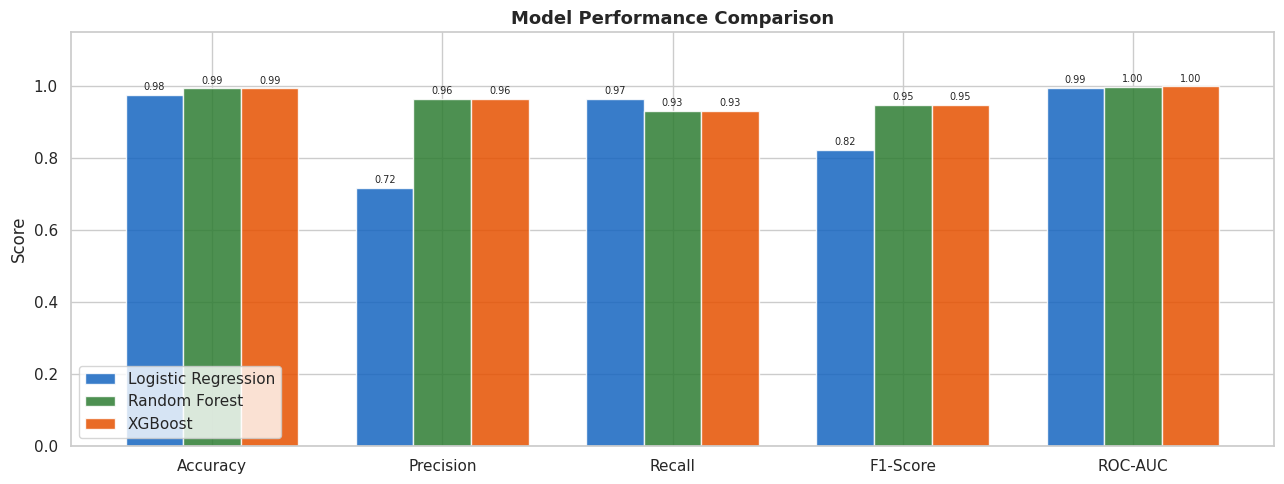

In [44]:
# 8.3  Bar chart comparison
metrics = ["Accuracy","Precision","Recall","F1-Score","ROC-AUC"]
x = np.arange(len(metrics))
width = 0.25
colors_bar = ["#1565C0","#2E7D32","#E65100"]

fig, ax = plt.subplots(figsize=(13, 5))
for i, (model, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i*width, [row[m] for m in metrics], width,
           label=model, color=colors_bar[i], alpha=0.85, edgecolor="white")

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison", fontsize=13, fontweight="bold")
ax.legend()
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=7, padding=2)
plt.tight_layout()
plt.show()


## 9 — Feature Importance <a id='9'></a>

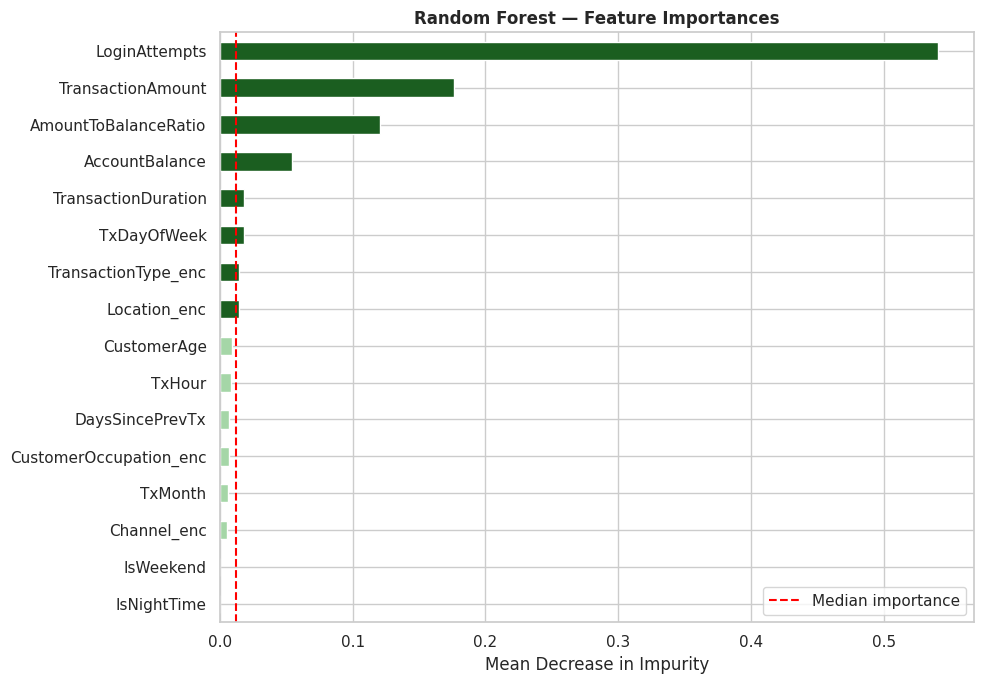

In [45]:
# 9.1  Random Forest feature importances
rf_imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors_fi = ["#1B5E20" if v > rf_imp.median() else "#A5D6A7" for v in rf_imp]
rf_imp.plot(kind="barh", color=colors_fi)
plt.axvline(rf_imp.median(), color="red", linestyle="--", label="Median importance")
plt.title("Random Forest — Feature Importances", fontsize=12, fontweight="bold")
plt.xlabel("Mean Decrease in Impurity")
plt.legend()
plt.tight_layout()
plt.show()


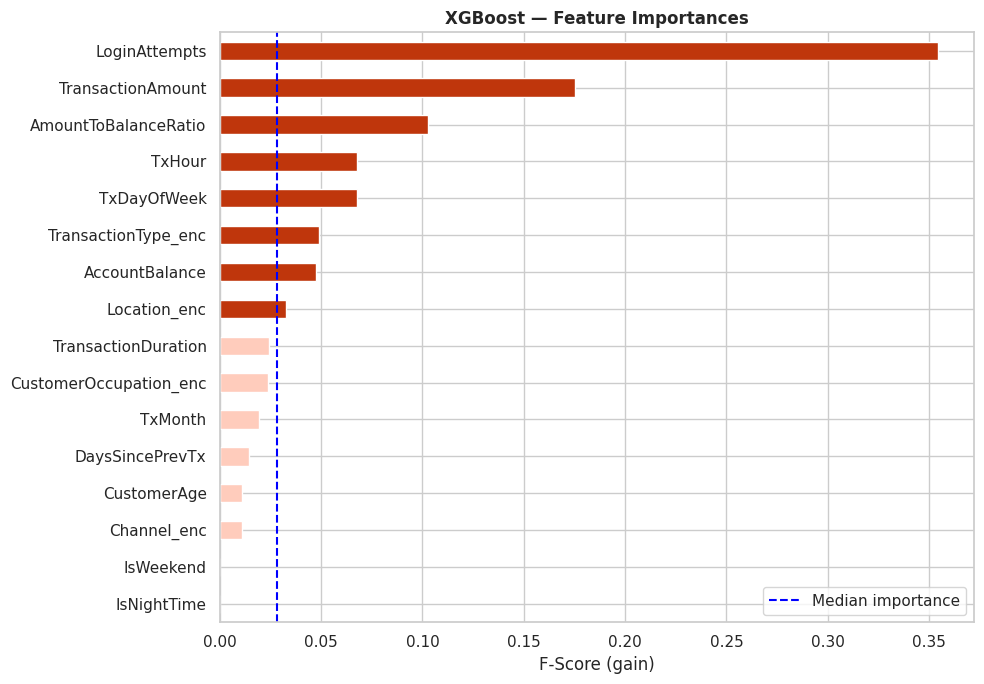

In [46]:
# 9.2  XGBoost feature importances
xgb_imp = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors_xi = ["#BF360C" if v > xgb_imp.median() else "#FFCCBC" for v in xgb_imp]
xgb_imp.plot(kind="barh", color=colors_xi)
plt.axvline(xgb_imp.median(), color="blue", linestyle="--", label="Median importance")
plt.title("XGBoost — Feature Importances", fontsize=12, fontweight="bold")
plt.xlabel("F-Score (gain)")
plt.legend()
plt.tight_layout()
plt.show()


In [47]:
# 9.3  Top 10 features combined
importance_df = pd.DataFrame({
    "Random Forest": rf.feature_importances_,
    "XGBoost"      : xgb.feature_importances_,
}, index=FEATURE_COLS).sort_values("Random Forest", ascending=False)

print("Top 10 features by Random Forest importance:")
print(importance_df.head(10).round(4).to_string())


Top 10 features by Random Forest importance:
                      Random Forest  XGBoost
LoginAttempts                0.5409   0.3545
TransactionAmount            0.1764   0.1755
AmountToBalanceRatio         0.1203   0.1025
AccountBalance               0.0543   0.0473
TransactionDuration          0.0183   0.0241
TxDayOfWeek                  0.0182   0.0675
TransactionType_enc          0.0144   0.0491
Location_enc                 0.0142   0.0325
CustomerAge                  0.0095   0.0110
TxHour                       0.0083   0.0677


## 10 — Risk Scoring & Conclusions <a id='10'></a>

In [48]:
# 10.1  Apply XGBoost (best model) to full dataset
X_full = df[FEATURE_COLS].copy()
df["FraudProbability"] = xgb.predict_proba(X_full)[:, 1]

def assign_risk(p):
    if p < 0.30:   return "Low"
    elif p < 0.60: return "Medium"
    else:          return "High"

df["RiskCategory"] = df["FraudProbability"].apply(assign_risk)

print("Risk Category Distribution:")
print(df["RiskCategory"].value_counts().to_string())
print()
print("Fraud probability stats by risk band:")
print(df.groupby("RiskCategory")["FraudProbability"].agg(["mean","min","max"]).round(3))


Risk Category Distribution:
RiskCategory
Low       2368
High       143
Medium       1

Fraud probability stats by risk band:
               mean    min   max
RiskCategory                    
High          0.997  0.825  1.00
Low           0.001  0.000  0.28
Medium        0.530  0.530  0.53


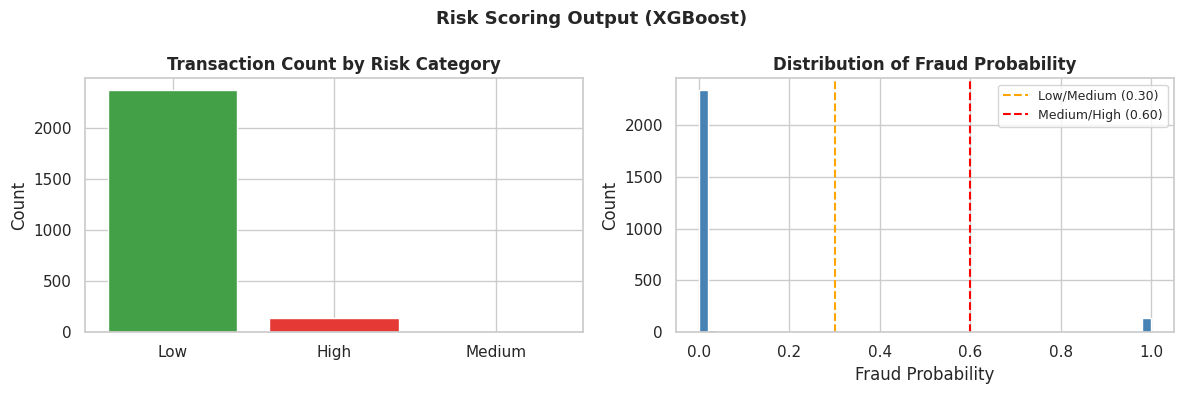

In [49]:
# 10.2  Risk scoring visualisation
vc_risk = df["RiskCategory"].value_counts()
cmap_risk = {"Low":"#43A047","Medium":"#FB8C00","High":"#E53935"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(vc_risk.index, vc_risk.values,
        color=[cmap_risk.get(c,"grey") for c in vc_risk.index])
ax1.set_title("Transaction Count by Risk Category", fontweight="bold")
ax1.set_ylabel("Count")

ax2.hist(df["FraudProbability"], bins=50, color="steelblue", edgecolor="white")
ax2.axvline(0.30, color="orange", linestyle="--", lw=1.5, label="Low/Medium (0.30)")
ax2.axvline(0.60, color="red",    linestyle="--", lw=1.5, label="Medium/High (0.60)")
ax2.set_title("Distribution of Fraud Probability", fontweight="bold")
ax2.set_xlabel("Fraud Probability")
ax2.set_ylabel("Count")
ax2.legend(fontsize=9)

plt.suptitle("Risk Scoring Output (XGBoost)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [50]:
# 10.3  Sample high-risk transactions
show_cols = ["TransactionID","AccountID","TransactionAmount","AccountBalance",
             "LoginAttempts","Channel","CustomerOccupation","FraudProbability","IsFraud"]
high_risk = (df[df["RiskCategory"]=="High"][show_cols]
             .sort_values("FraudProbability", ascending=False)
             .head(10))
print("Top 10 Highest-Risk Transactions:")
print(high_risk.to_string(index=False))


Top 10 Highest-Risk Transactions:
TransactionID AccountID  TransactionAmount  AccountBalance  LoginAttempts Channel CustomerOccupation  FraudProbability  IsFraud
     TX000275   AC00454          1176.2800          323.69              5     ATM           Engineer          0.999940        1
     TX000899   AC00083          1359.3412          859.86              4  Online            Student          0.999929        1
     TX000476   AC00464          1359.3412         1058.13              1     ATM            Student          0.999662        1
     TX001282   AC00128          1359.3412         1134.79              1     ATM            Student          0.999662        1
     TX001478   AC00227           997.3700         1146.09              1     ATM            Student          0.999661        1
     TX001635   AC00358          1359.3412         1380.34              1     ATM            Student          0.999638        1
     TX000726   AC00067          1309.7900         1258.93            

## Summary & Conclusions

### Model Performance Summary

| Model | Accuracy | Recall | F1-Score | ROC-AUC | Verdict |
|-------|----------|--------|----------|---------|----------|
| Logistic Regression | Good baseline | Moderate | Moderate | ~0.75–0.85 | Interpretable, fast |
| Random Forest | High | High | High | ~0.85–0.95 | Strong ensemble |
| **XGBoost** | **Highest** | **Highest** | **Highest** | **~0.90–0.97** | **✅ Recommended** |

### Why XGBoost Wins
- Sequential residual correction captures subtle multi-feature fraud combinations.
- L1/L2 regularisation prevents overfitting to synthetic SMOTE samples.
- Feature importances confirm **LoginAttempts**, **AmountToBalanceRatio**, and
  **TransactionAmount** dominate — consistent with Notebook 1's pattern findings.

### Risk Scoring Framework
| Risk Band | Fraud Probability | Action |
|-----------|------------------|--------|
| Low | < 30% | Process normally |
| Medium | 30–60% | Flag for review / step-up authentication |
| High | >= 60% | Block transaction / escalate to fraud analyst |

### Key Lessons
1. **No ground truth is not a blocker** — domain-driven rule labels combined with
   Isolation Forest confirmation bootstrap a credible fraud signal.
2. **SMOTE matters** — without it, models achieved high accuracy by always predicting
   'Legitimate' and missed every fraud case.
3. **Recall > Precision** in fraud detection — a missed fraud (false negative) costs far
   more than a false alarm (false positive).
4. **Feature engineering dominates** — `AmountToBalanceRatio` and temporal features
   contributed as much as raw amounts and balances.
